In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from scipy.signal import convolve2d

In [2]:
with rasterio.open("../data/Sonoma_DTM_2022-OAEC-0.01-degree.tif") as file:
    elevation = file.read(1)
    transform = file.transform
    crs = file.crs
    left, bottom, right, top = file.bounds

In [3]:
water = gpd.read_file("../data/oaec-water.gpkg").to_crs(crs)
roads = gpd.read_file("../data/oaec-roads.gpkg").to_crs(crs)

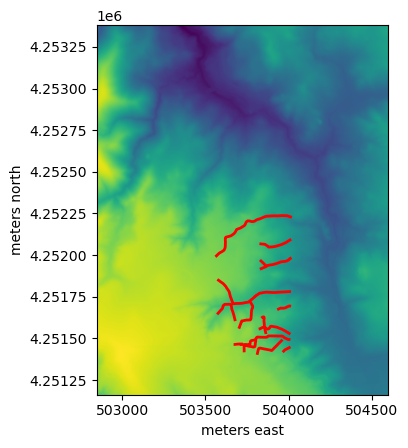

In [4]:
fig, ax = plt.subplots()

ax.imshow(elevation, extent=(left, right, bottom, top), origin="upper")

water.plot(ax=ax, edgecolor="red", linewidth=2)

ax.set_xlabel("meters east")
ax.set_ylabel("meters north")

None

In [5]:
def make_kernel(radius):
    width = 2 * radius + 1
    x, y = np.meshgrid(np.arange(width), np.arange(width))
    disk = (x - radius)**2 + (y - radius)**2 <= radius**2
    disk[radius, radius] = False
    out = np.zeros((width, width))
    out[radius, radius] = 1
    out[disk] = -1 / np.sum(disk)
    return out

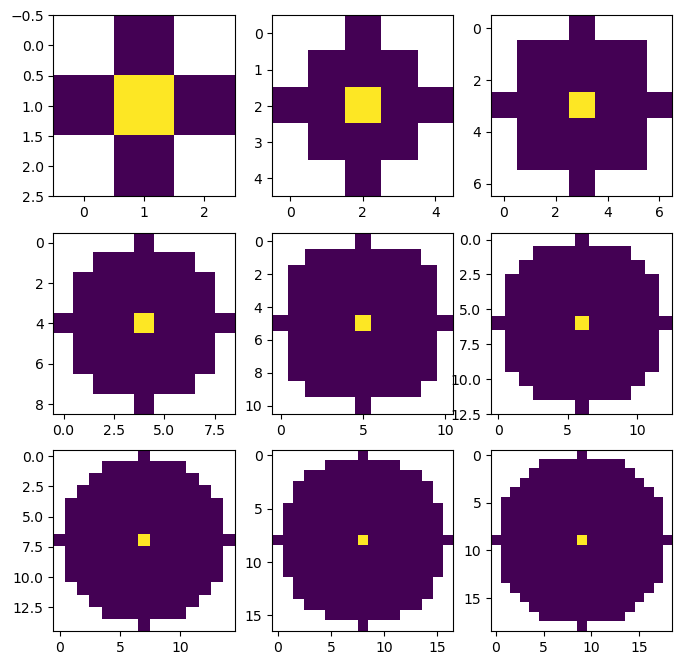

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axs.flatten()):
    tmp = make_kernel(i + 1)
    tmp[tmp == 0] = np.nan
    ax.imshow(tmp)

None

In [7]:
convolutions = {5: None, 10: None, 15: None, 20: None, 25: None, 30: None, 35: None, 40: None, 45: None, 50: None}

In [8]:
convolutions[5] = convolve2d(elevation, make_kernel(5), mode="same", boundary="symm")

In [9]:
convolutions[10] = convolve2d(elevation, make_kernel(10), mode="same", boundary="symm")

In [10]:
convolutions[15] = convolve2d(elevation, make_kernel(15), mode="same", boundary="symm")

In [11]:
convolutions[20] = convolve2d(elevation, make_kernel(20), mode="same", boundary="symm")

In [12]:
convolutions[25] = convolve2d(elevation, make_kernel(25), mode="same", boundary="symm")

In [13]:
convolutions[30] = convolve2d(elevation, make_kernel(30), mode="same", boundary="symm")

In [14]:
convolutions[35] = convolve2d(elevation, make_kernel(35), mode="same", boundary="symm")

In [15]:
convolutions[40] = convolve2d(elevation, make_kernel(40), mode="same", boundary="symm")

In [16]:
convolutions[45] = convolve2d(elevation, make_kernel(45), mode="same", boundary="symm")

In [17]:
convolutions[50] = convolve2d(elevation, make_kernel(50), mode="same", boundary="symm")

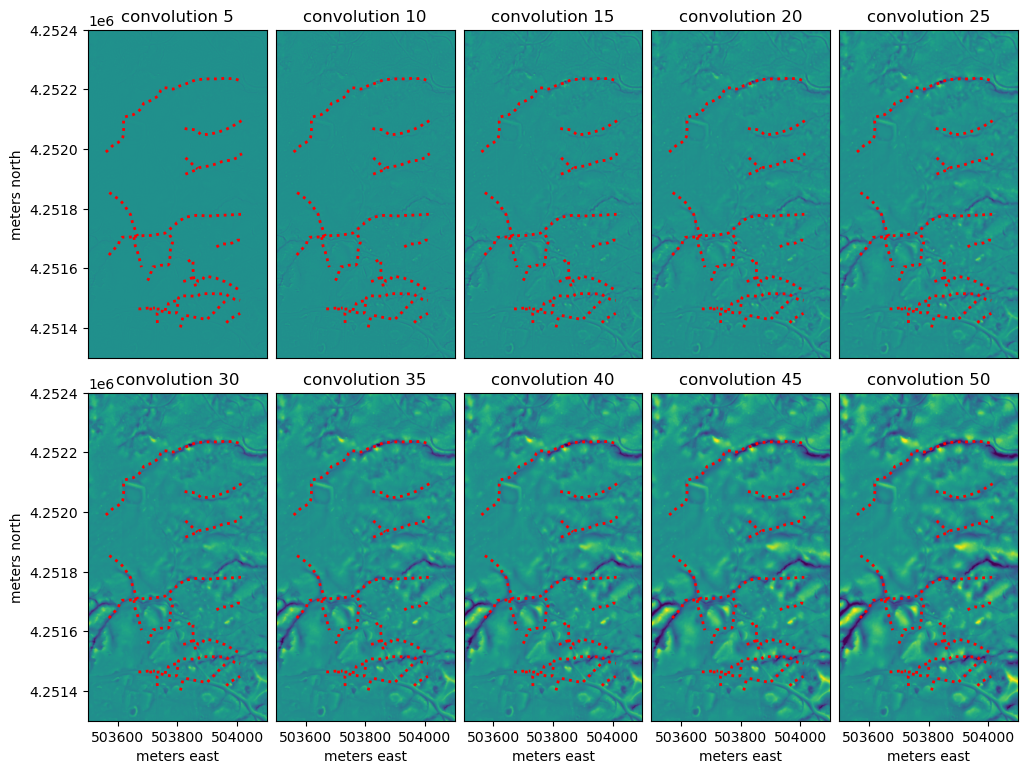

In [21]:
fig, axs = plt.subplots(2, 5, figsize=(12, 9))

for key, ax in zip(convolutions, axs.flatten()):
    ax.imshow(convolutions[key], vmin=-5, vmax=5, extent=(left, right, bottom, top), origin="upper")
    water.plot(ax=ax, edgecolor="red", lw=2, ls=":", alpha=1)

    ax.set_title(f"convolution {key}")
    ax.set_xlim(503500, 504100)
    ax.set_ylim(4251300, 4252400)
    if key in (30, 35, 40, 45, 50):
        ax.set_xlabel("meters east")
    else:
        ax.set_xticks([])
    if key in (5, 30):
        ax.set_ylabel("meters north")
    else:
        ax.set_yticks([])

plt.subplots_adjust(wspace=0.05, hspace=0.10)

None

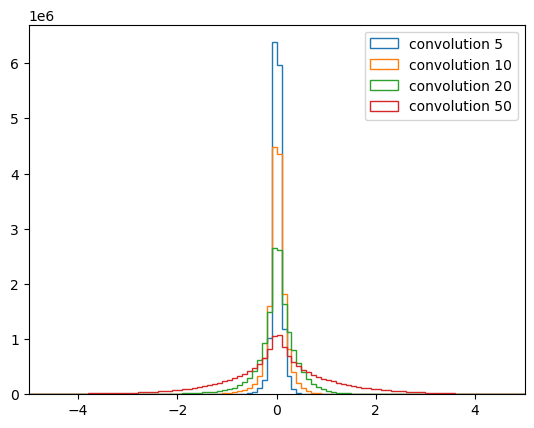

In [52]:
fig, ax = plt.subplots()

for key in (5, 10, 20, 50):
    ax.hist(convolutions[key].flatten(), bins=100, range=(-5, 5), histtype="step", label=f"convolution {key}")

ax.set_xlim(-5, 5)
ax.legend(loc="upper right")

None

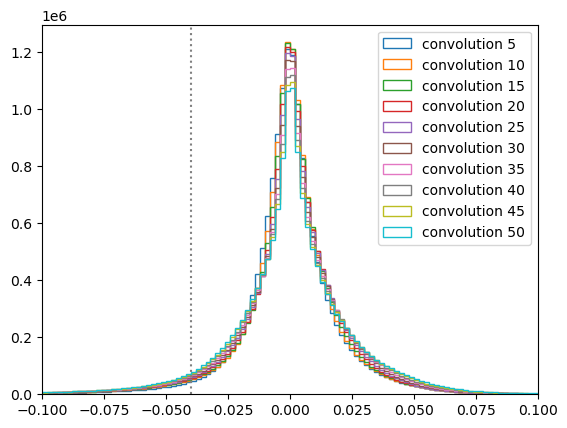

In [97]:
fig, ax = plt.subplots()

for key in convolutions:
    ax.hist(convolutions[key].flatten() / key, bins=100, range=(-0.1, 0.1), histtype="step", label=f"convolution {key}")

ax.axvline(-0.04, c="gray", ls=":")

ax.set_xlim(-0.1, 0.1)
ax.legend(loc="upper right")

None

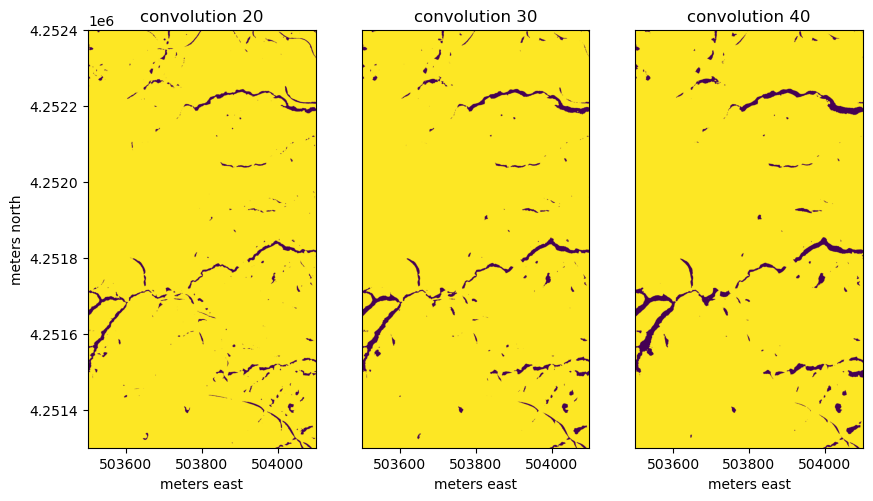

In [98]:
fig, axs = plt.subplots(1, 3, figsize=(10, 8))

for key, ax in zip((20, 30, 40), axs):
    ax.imshow(convolutions[key] / key > -0.04, extent=(left, right, bottom, top), origin="upper")
    # water.plot(ax=ax, edgecolor="red", lw=2, ls=":", alpha=0.5)

    ax.set_title(f"convolution {key}")
    ax.set_xlim(503500, 504100)
    ax.set_ylim(4251300, 4252400)
    ax.set_xlabel("meters east")
    if key == 20:
        ax.set_ylabel("meters north")
    else:
        ax.set_yticks([])

None

In [99]:
KEY = 30  # half-meters
CUT = -0.04 * 30  # meters

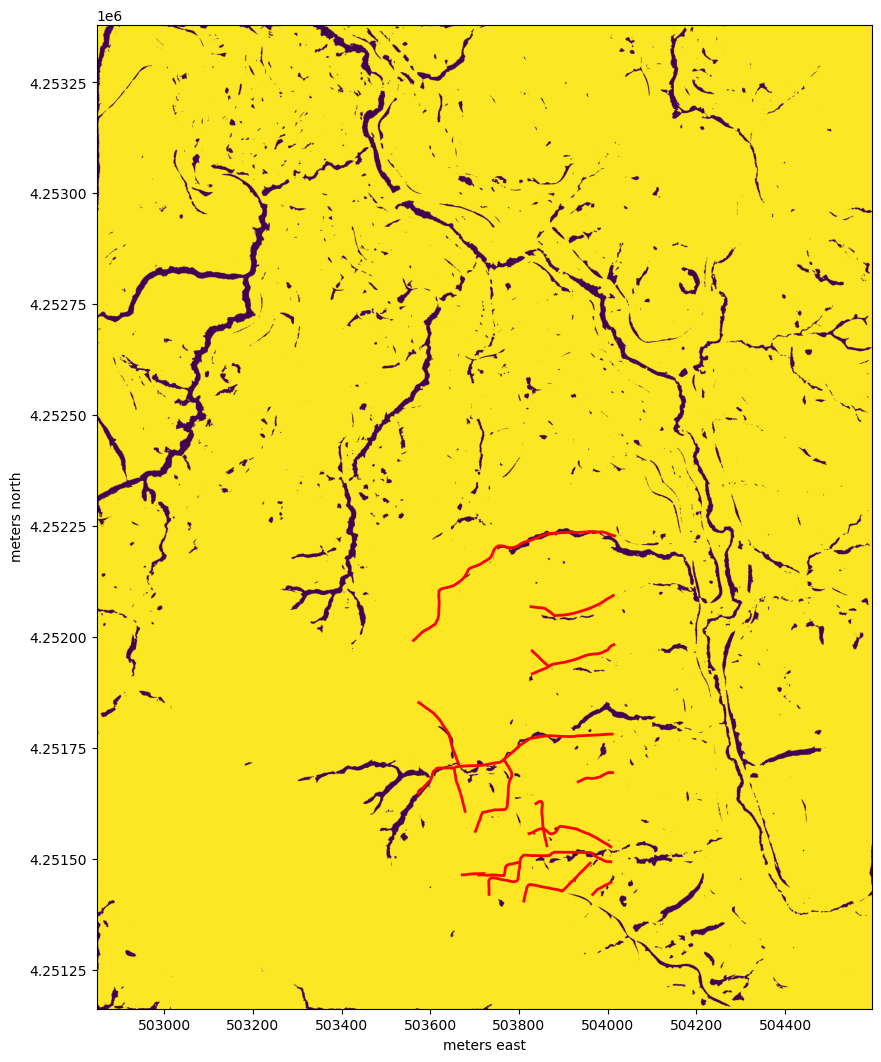

In [100]:
fig, ax = plt.subplots(figsize=(10, 20))

ax.imshow(convolutions[KEY] > CUT, extent=(left, right, bottom, top), origin="upper")

water.plot(ax=ax, edgecolor="red", linewidth=2)

ax.set_xlabel("meters east")
ax.set_ylabel("meters north")

None

In [101]:
with rasterio.open(
    "evans-lindsay-0.01-degree.tif",
    "w",
    driver="GTiff",
    height=elevation.shape[0],
    width=elevation.shape[1],
    count=1,
    dtype=np.uint8,
    crs=crs,
    transform=transform,
) as file:
    file.write(convolutions[KEY] > CUT, 1)